## Importarção de bibliotecas, configuração e carregamento do dataset

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [154]:
'''
Usei o parâmetro decimal porque existem algumas colunas mal formatadas com ',' ao invés de '.'. A função read_csv do pandas tem o decimal, passando ',' como argumento
a engine vai entender que isso deveria ser um '.' é vai formatar.
'''
pd.options.display.float_format = '{:.0f}'.format
df = pd.read_csv('dados_reduzidos.csv', sep=';', decimal=',')
df.head()

,id,valor_total,area_util,quartos,vagas,valor_condominio,suites,banheiros,piscina,academia,...,bairro,qtd_dados_bairro,media_idh,expectativa_vida,renda_percapita,estacao_prox,linha_prox,dist,lat,lon
0,526,189900,32,2,1,180,0,1,0,1,...,JOSE BONIFACIO,36,1,73,560,SÃO MATEUS,PRATA,6823,-24,-46
1,734,221110,43,2,1,250,0,1,0,0,...,JOSE BONIFACIO,36,1,73,560,CORINTHIANS-ITAQUERA,VERMELHA,4683,-24,-46
2,738,219990,43,1,1,300,0,1,1,0,...,JOSE BONIFACIO,36,1,73,560,CORINTHIANS-ITAQUERA,VERMELHA,4579,-24,-46
3,753,219990,43,2,1,300,0,1,1,0,...,JOSE BONIFACIO,36,1,73,560,CORINTHIANS-ITAQUERA,VERMELHA,4579,-24,-46
4,924,220000,41,2,1,300,0,1,1,1,...,JOSE BONIFACIO,36,1,73,560,CORINTHIANS-ITAQUERA,VERMELHA,3314,-24,-46


In [155]:
df.columns

Index(['id', 'valor_total', 'area_util', 'quartos', 'vagas',
       'valor_condominio', 'suites', 'banheiros', 'piscina', 'academia',
       'quadra', 'link', 'bairro', 'qtd_dados_bairro', 'media_idh',
       'expectativa_vida', 'renda_percapita', 'estacao_prox', 'linha_prox',
       'dist', 'lat', 'lon'],
      dtype='str')

In [156]:
df.info() #existem 2499 linhas, 22 colunas e não existem valores nulos

<class 'pandas.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                2499 non-null   int64  
 1   valor_total       2499 non-null   int64  
 2   area_util         2499 non-null   int64  
 3   quartos           2499 non-null   int64  
 4   vagas             2499 non-null   int64  
 5   valor_condominio  2264 non-null   float64
 6   suites            2499 non-null   int64  
 7   banheiros         2499 non-null   int64  
 8   piscina           2499 non-null   int64  
 9   academia          2499 non-null   int64  
 10  quadra            2499 non-null   int64  
 11  link              2499 non-null   str    
 12  bairro            2499 non-null   str    
 13  qtd_dados_bairro  2492 non-null   float64
 14  media_idh         2499 non-null   float64
 15  expectativa_vida  2499 non-null   float64
 16  renda_percapita   2499 non-null   float64
 17  estaca

In [157]:
df.describe()

,id,valor_total,area_util,quartos,vagas,valor_condominio,suites,banheiros,piscina,academia,quadra,qtd_dados_bairro,media_idh,expectativa_vida,renda_percapita,dist,lat,lon
count,2499,2499,2499,2499,2499,2264,2499,2499,2499,2499,2499,2492,2499,2499,2499,2499,2499,2499
mean,1290,548085,71,2,1,1720,1,2,0,0,0,22,1,77,1584,2851,-24,-47
std,741,554449,45,1,1,28049,1,1,0,0,0,10,0,2,1109,2741,0,0
min,1,80000,22,1,0,1,0,1,0,0,0,1,1,72,523,31,-24,-47
25%,650,265000,49,2,1,350,0,1,0,0,0,15,1,75,863,926,-24,-47
50%,1292,380000,60,2,1,486,0,1,0,0,0,21,1,77,1243,2030,-24,-47
75%,1932,598500,74,3,1,650,1,2,1,0,1,28,1,78,1789,3844,-24,-47
max,2570,12000000,640,5,39,857000,4,8,1,1,1,51,1,82,6721,26101,-23,-46


## Análise Descritiva

### Váriaveis Quantitivas 

In [158]:
# análise das variáveis numéricas
numeric_columns = df.select_dtypes(include=[np.number]).columns.drop('id', errors='ignore')
numeric_columns


Index(['valor_total', 'area_util', 'quartos', 'vagas', 'valor_condominio',
       'suites', 'banheiros', 'piscina', 'academia', 'quadra',
       'qtd_dados_bairro', 'media_idh', 'expectativa_vida', 'renda_percapita',
       'dist', 'lat', 'lon'],
      dtype='str')

#### Histogramas

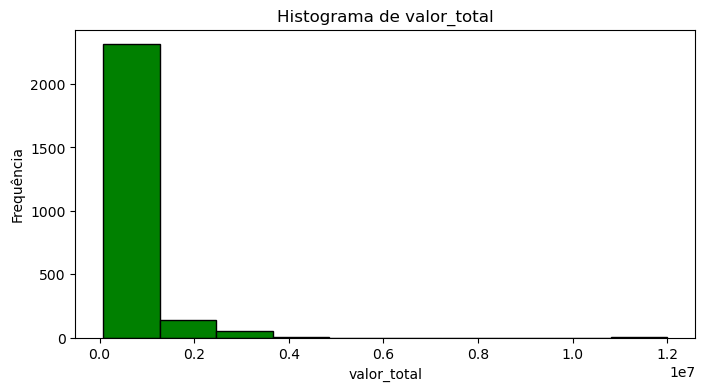

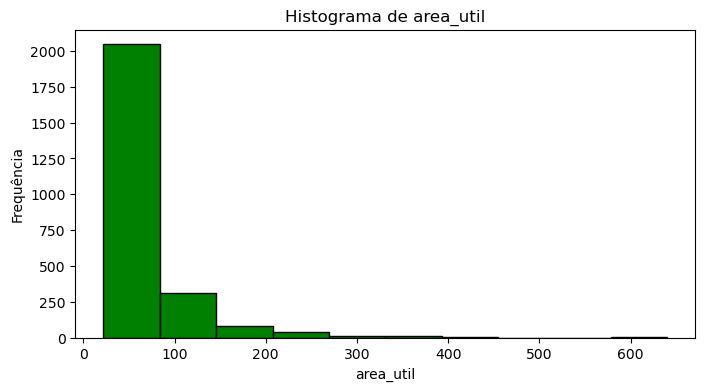

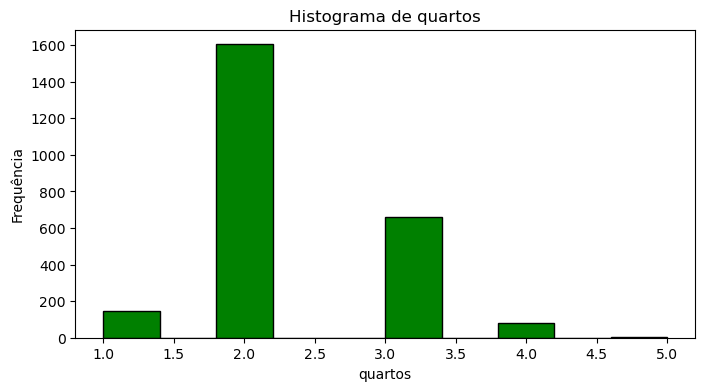

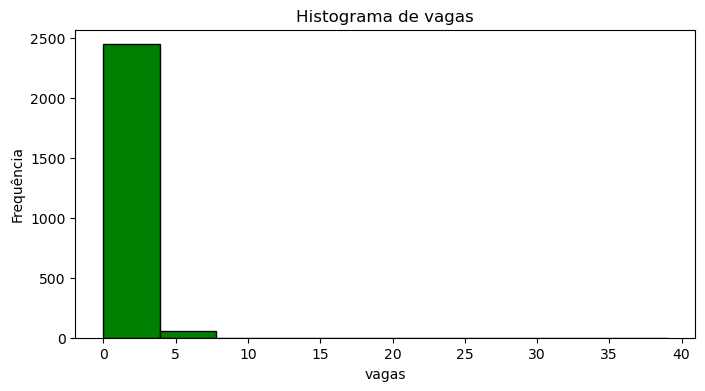

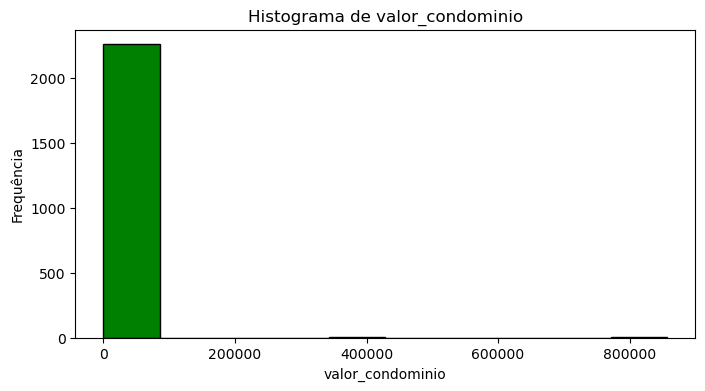

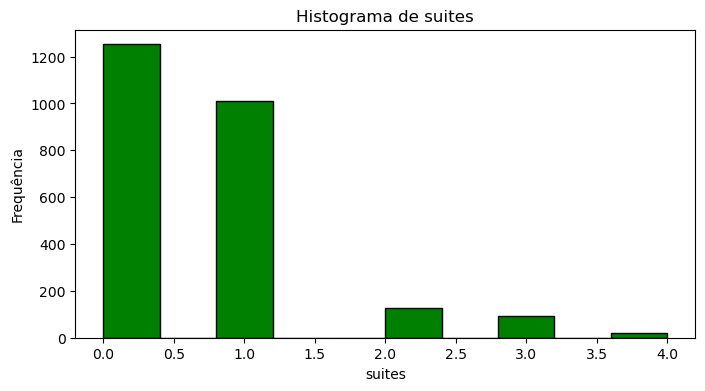

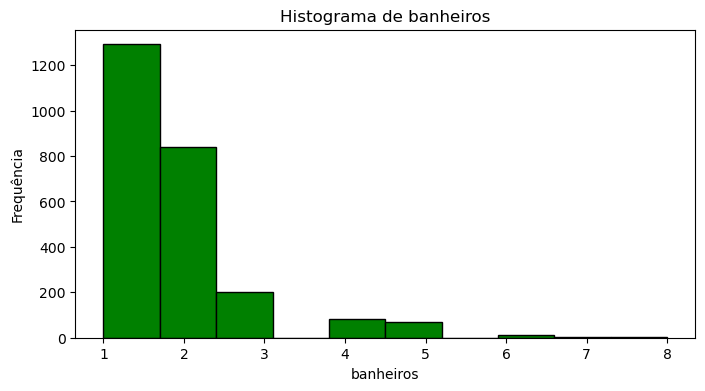

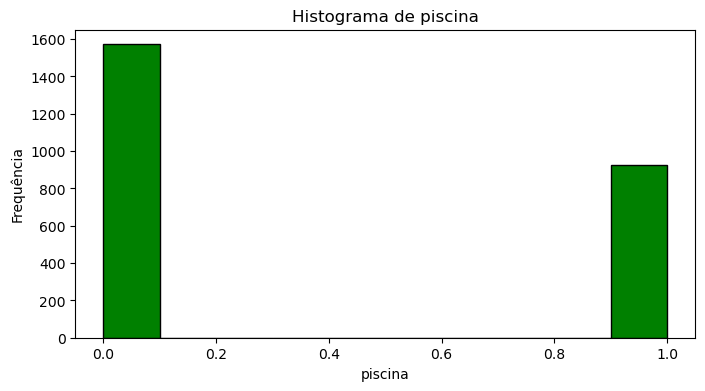

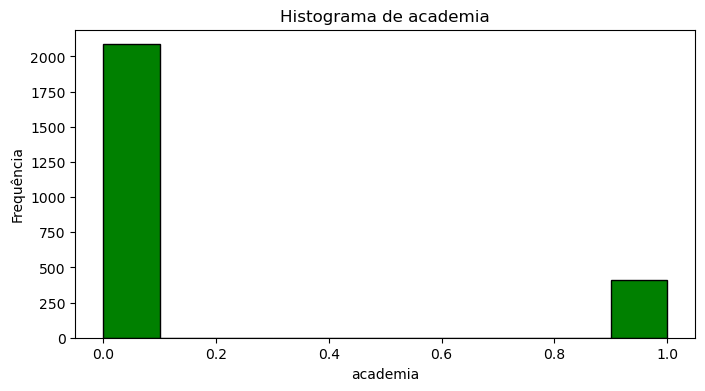

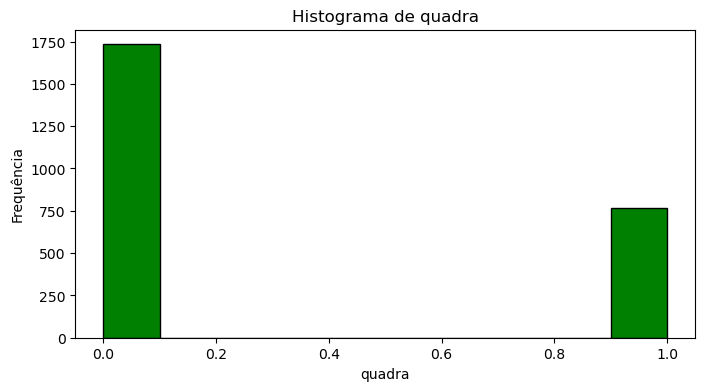

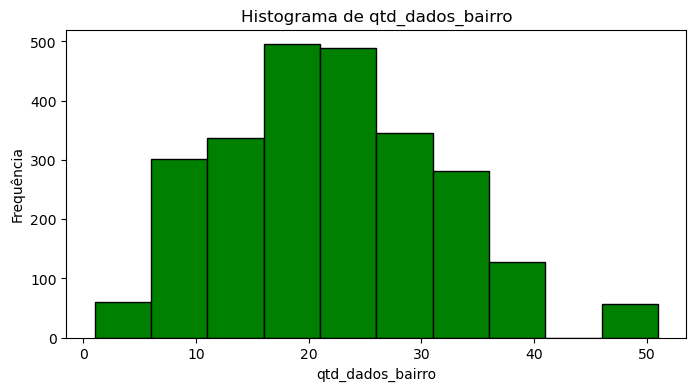

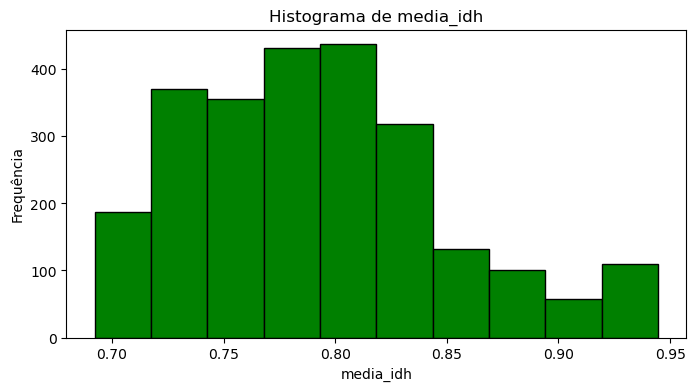

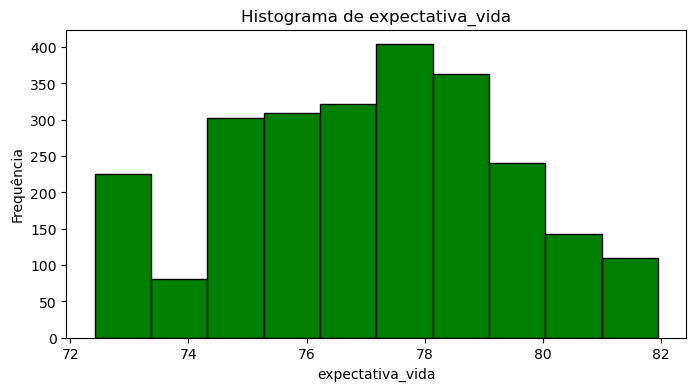

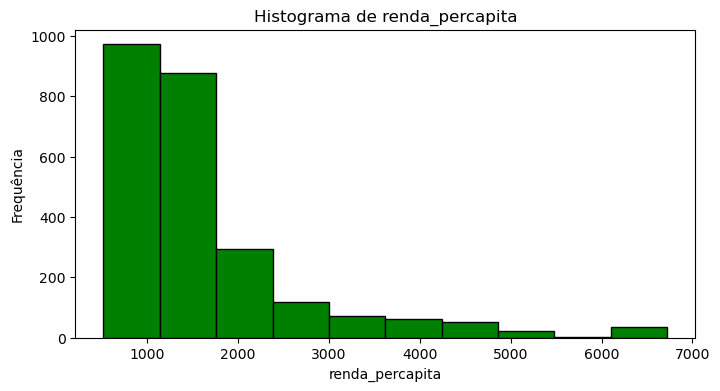

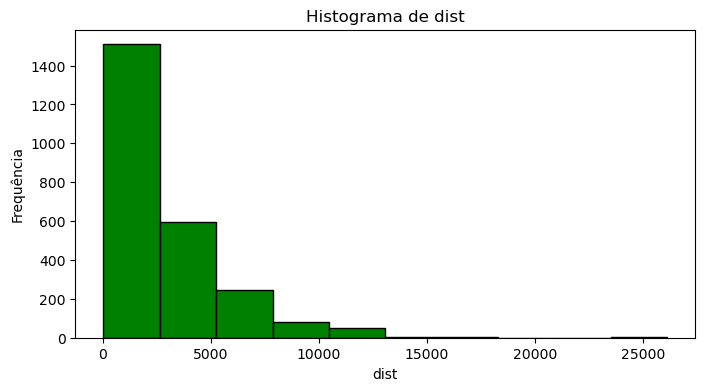

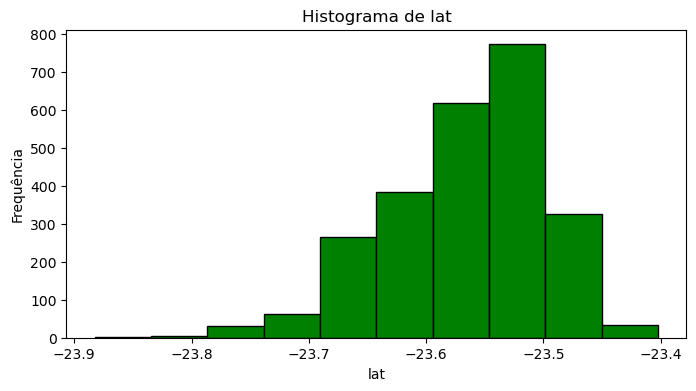

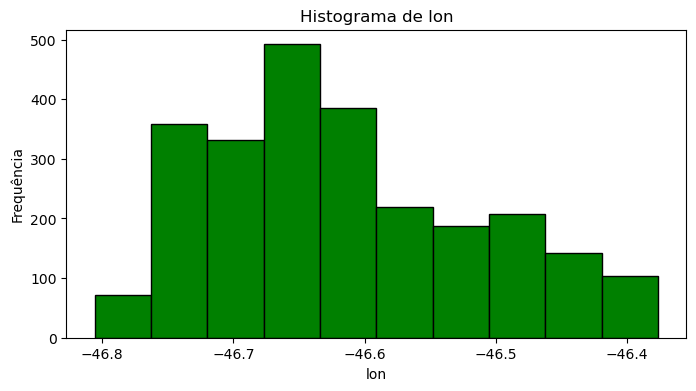

In [159]:
for column in numeric_columns:
    data = df[column].dropna()  
    
    plt.figure(figsize=(8, 4))
    plt.hist(data, bins=10,color='green' ,edgecolor='black')
    plt.title(f"Histograma de {column}")
    plt.xlabel(column)
    plt.ylabel("Frequência")
    plt.show()

#### Boxplot

<Axes: >

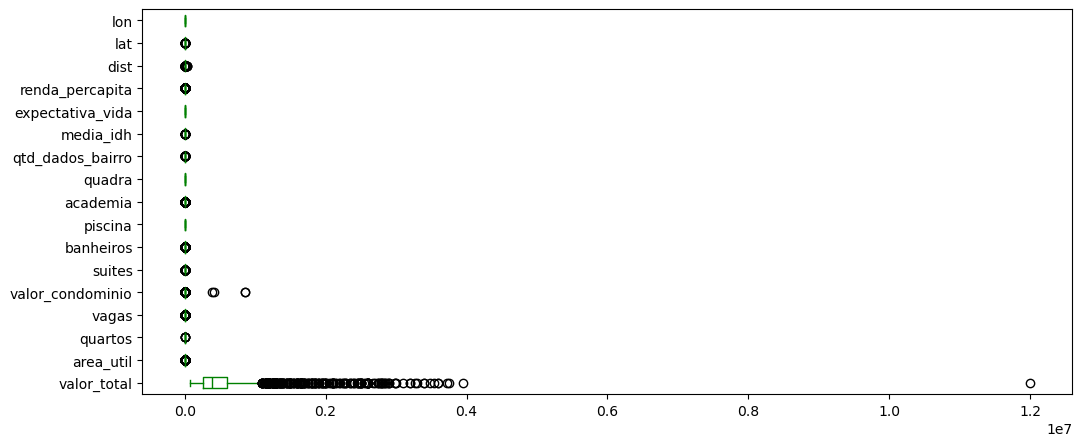

In [160]:
# for column in numeric_columns:  

df[numeric_columns].plot.box(figsize=(12, 5), vert=False, color='green')


### Variáveis Qualitativas

In [161]:
categoric_columns = df.select_dtypes(include=['str']).columns
categoric_columns

Index(['link', 'bairro', 'estacao_prox', 'linha_prox'], dtype='str')

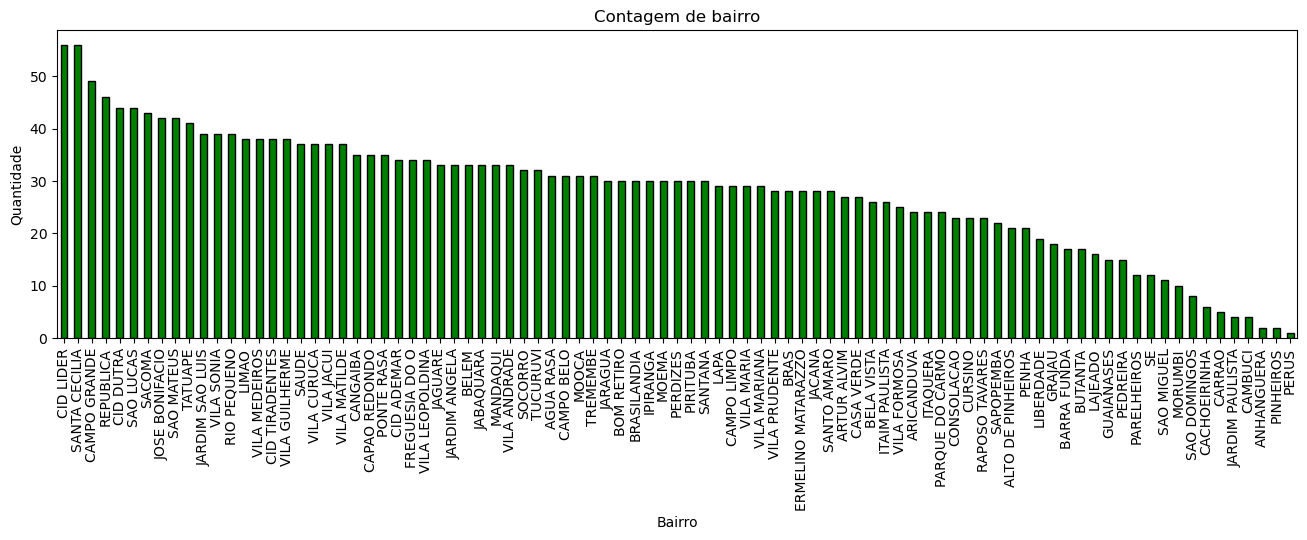

In [162]:
#Bairro 
unique_bairros = df['bairro'].value_counts()
unique_bairros

plt.figure(figsize=(16, 4))
unique_bairros.plot(kind='bar', color='green', edgecolor='black')
plt.title(f"Contagem de bairro")
plt.xlabel("Bairro")
plt.ylabel("Quantidade")
plt.xticks(rotation=90)
plt.show()

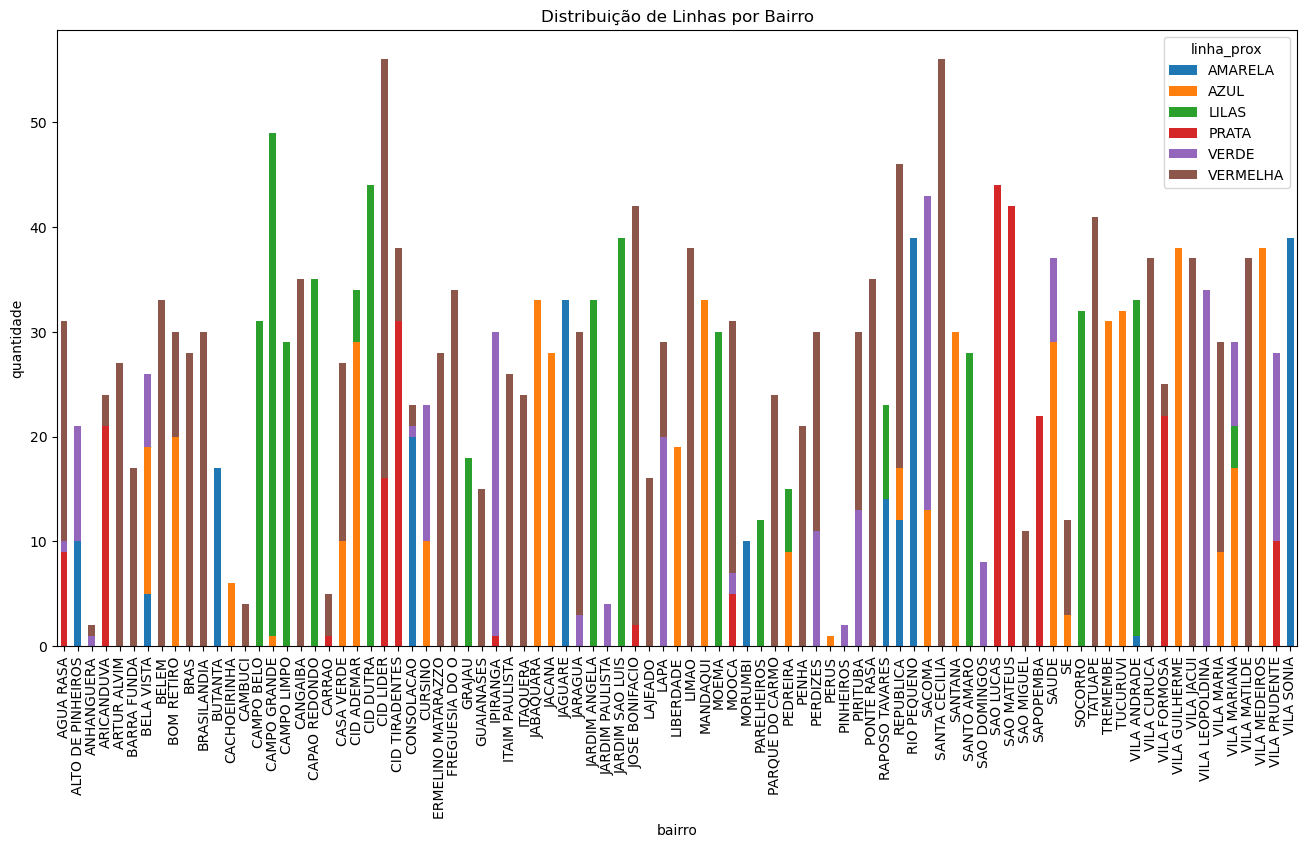

In [163]:
contagem_detalhada = df.groupby(['bairro', 'linha_prox']).size().unstack()

# Linhas próximas por cada bairro:plotei empilhado porque tava muito difícil visualizar os dados sem stacked 
contagem_detalhada.plot(kind='bar', stacked=True, figsize=(16, 8))
plt.title('Distribuição de Linhas por Bairro')
plt.ylabel('quantidade')
plt.show()

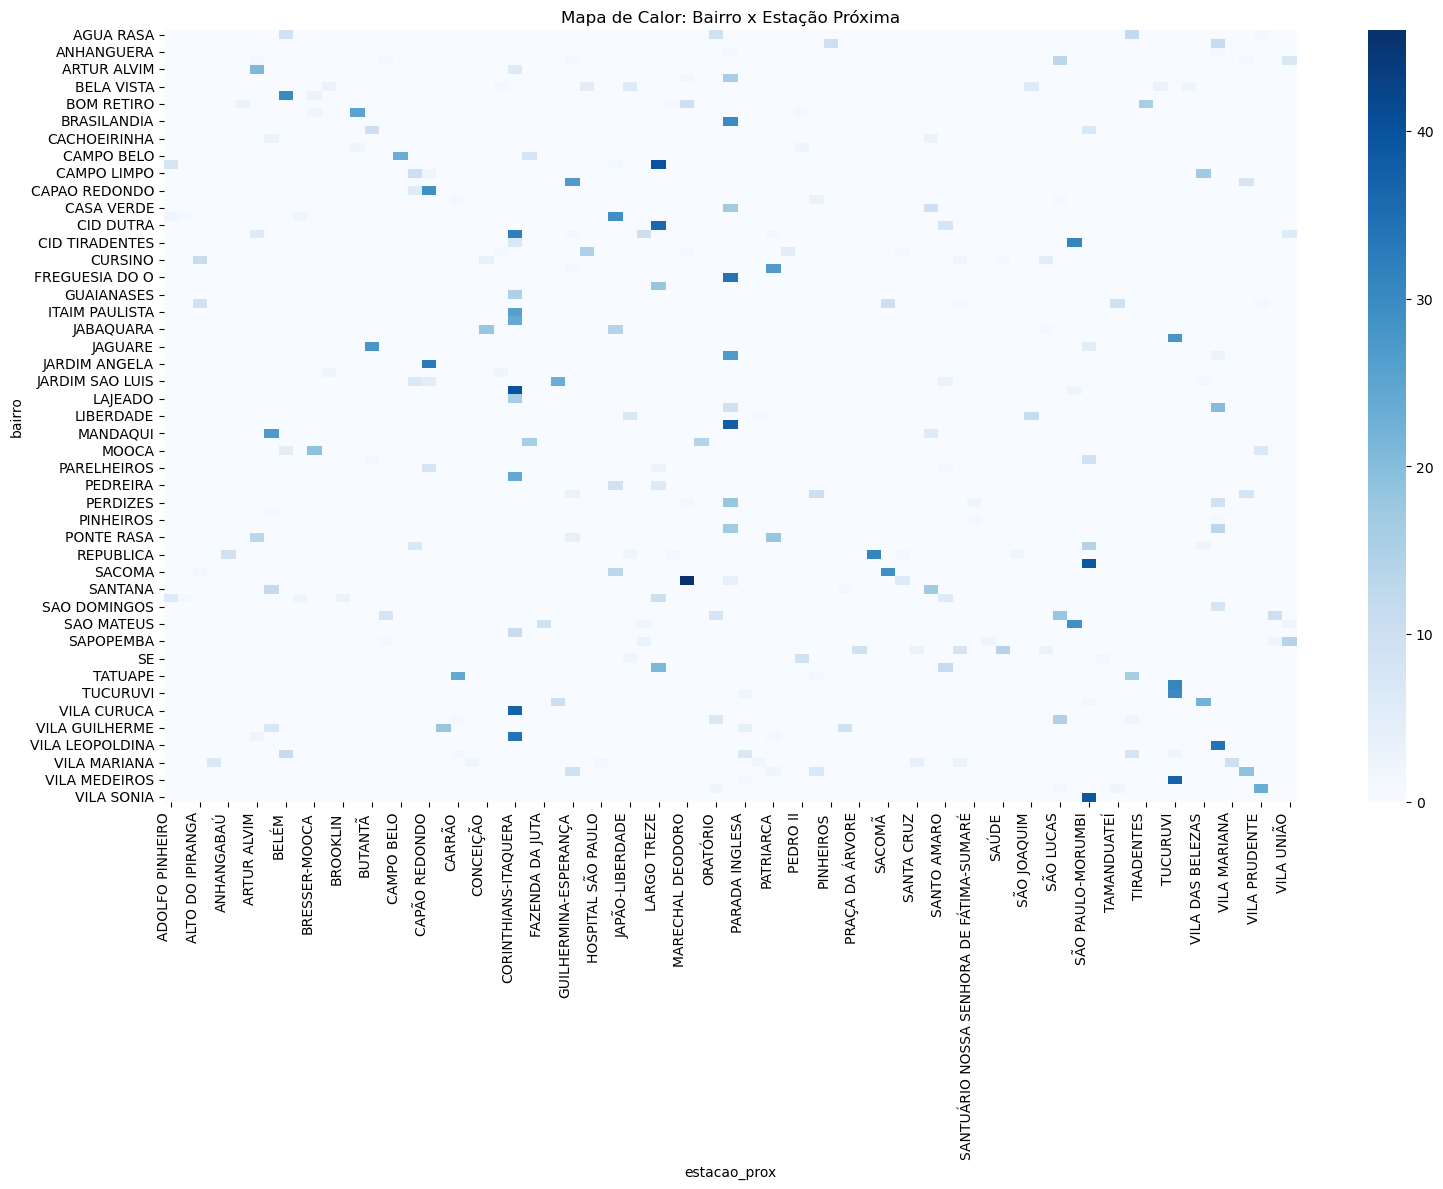

In [178]:
contagem_detalhada = df.groupby(['bairro', 'estacao_prox']).size().unstack()

df_heatmap = contagem_detalhada.fillna(0)

plt.figure(figsize=(16, 12))
sns.heatmap(df_heatmap, cmap='Blues', annot=False, fmt='g')
plt.title('Mapa de Calor: Bairro x Estação Próxima')
plt.ylabel('bairro')
plt.xlabel('estacao_prox')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

<Axes: ylabel='bairro'>

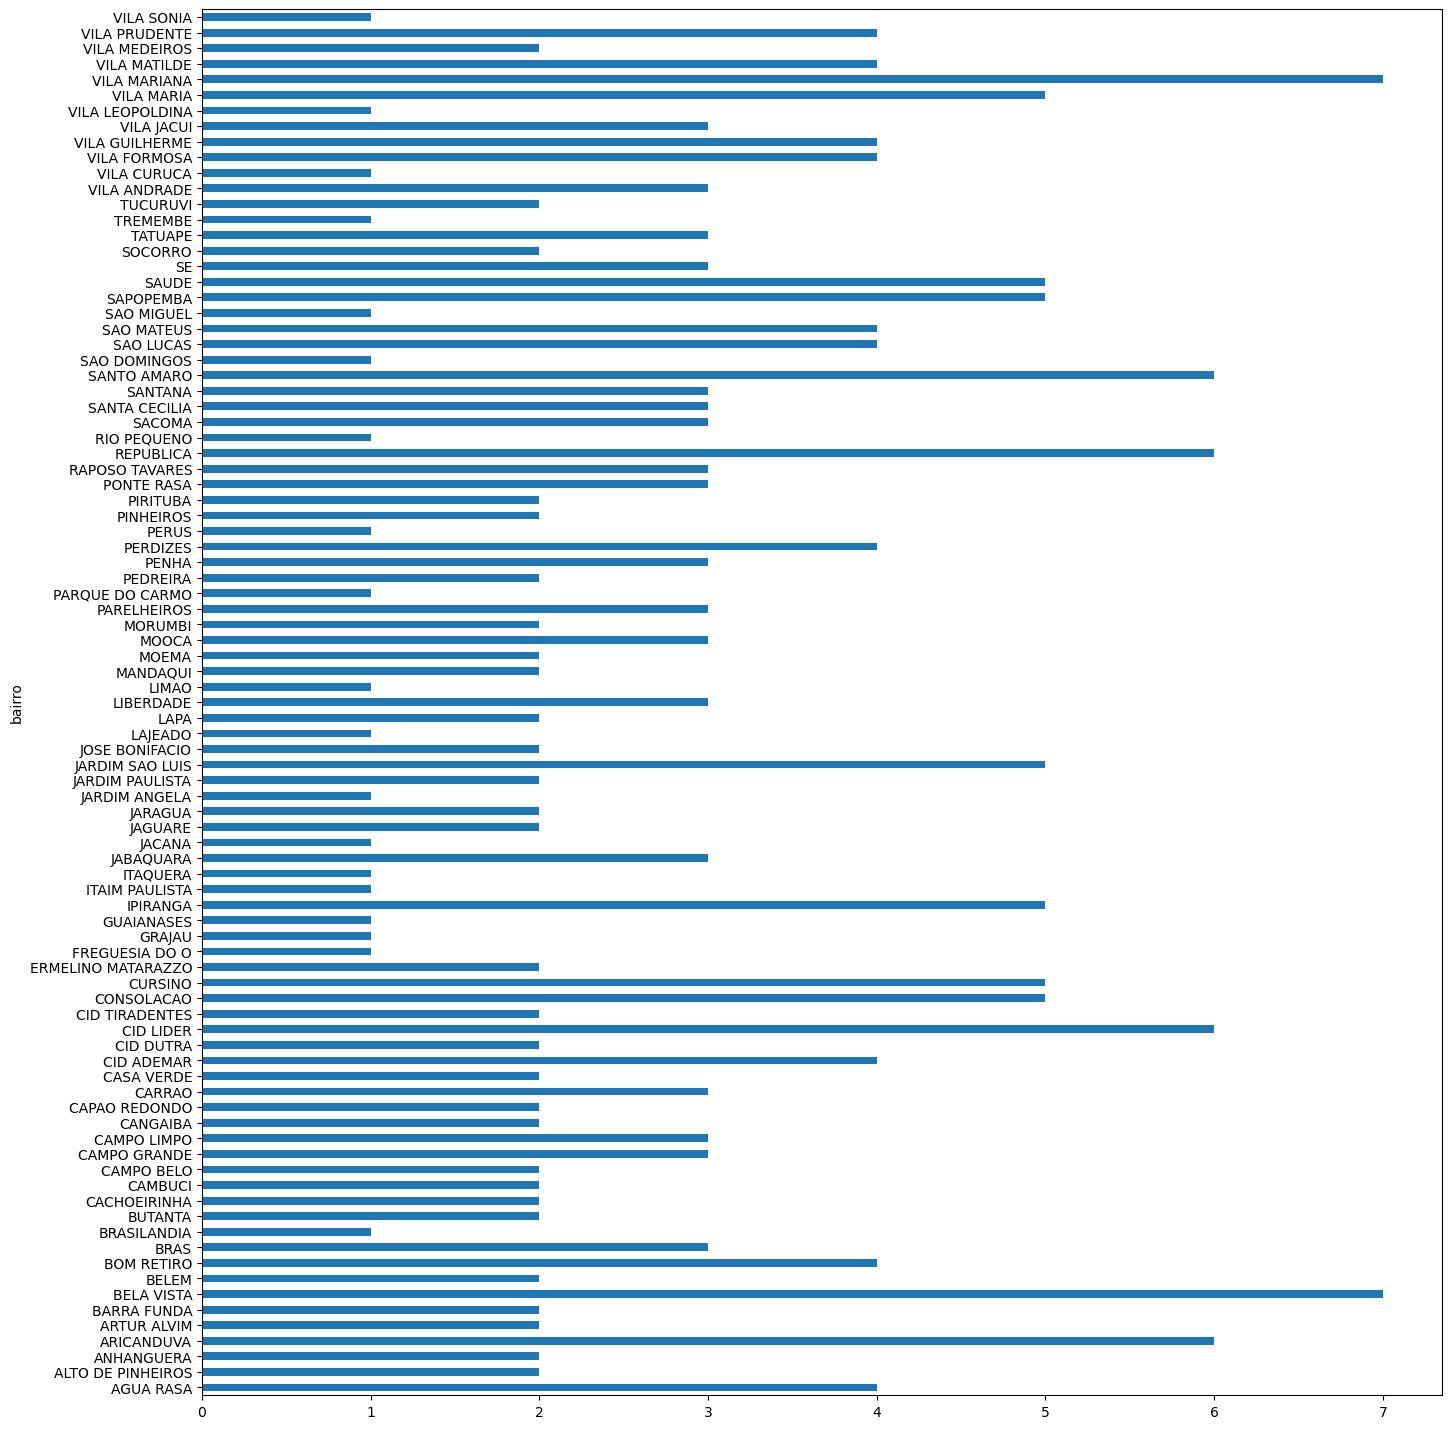

In [202]:
bairro_estacoes_unicas = df.groupby('bairro')['estacao_prox'].nunique()
bairro_estacoes_unicas

bairro_estacoes_unicas.plot(kind='barh', figsize=(16, 18))


<Axes: title={'center': 'Valor Médio Por Bairro'}, xlabel='valor', ylabel='bairro'>

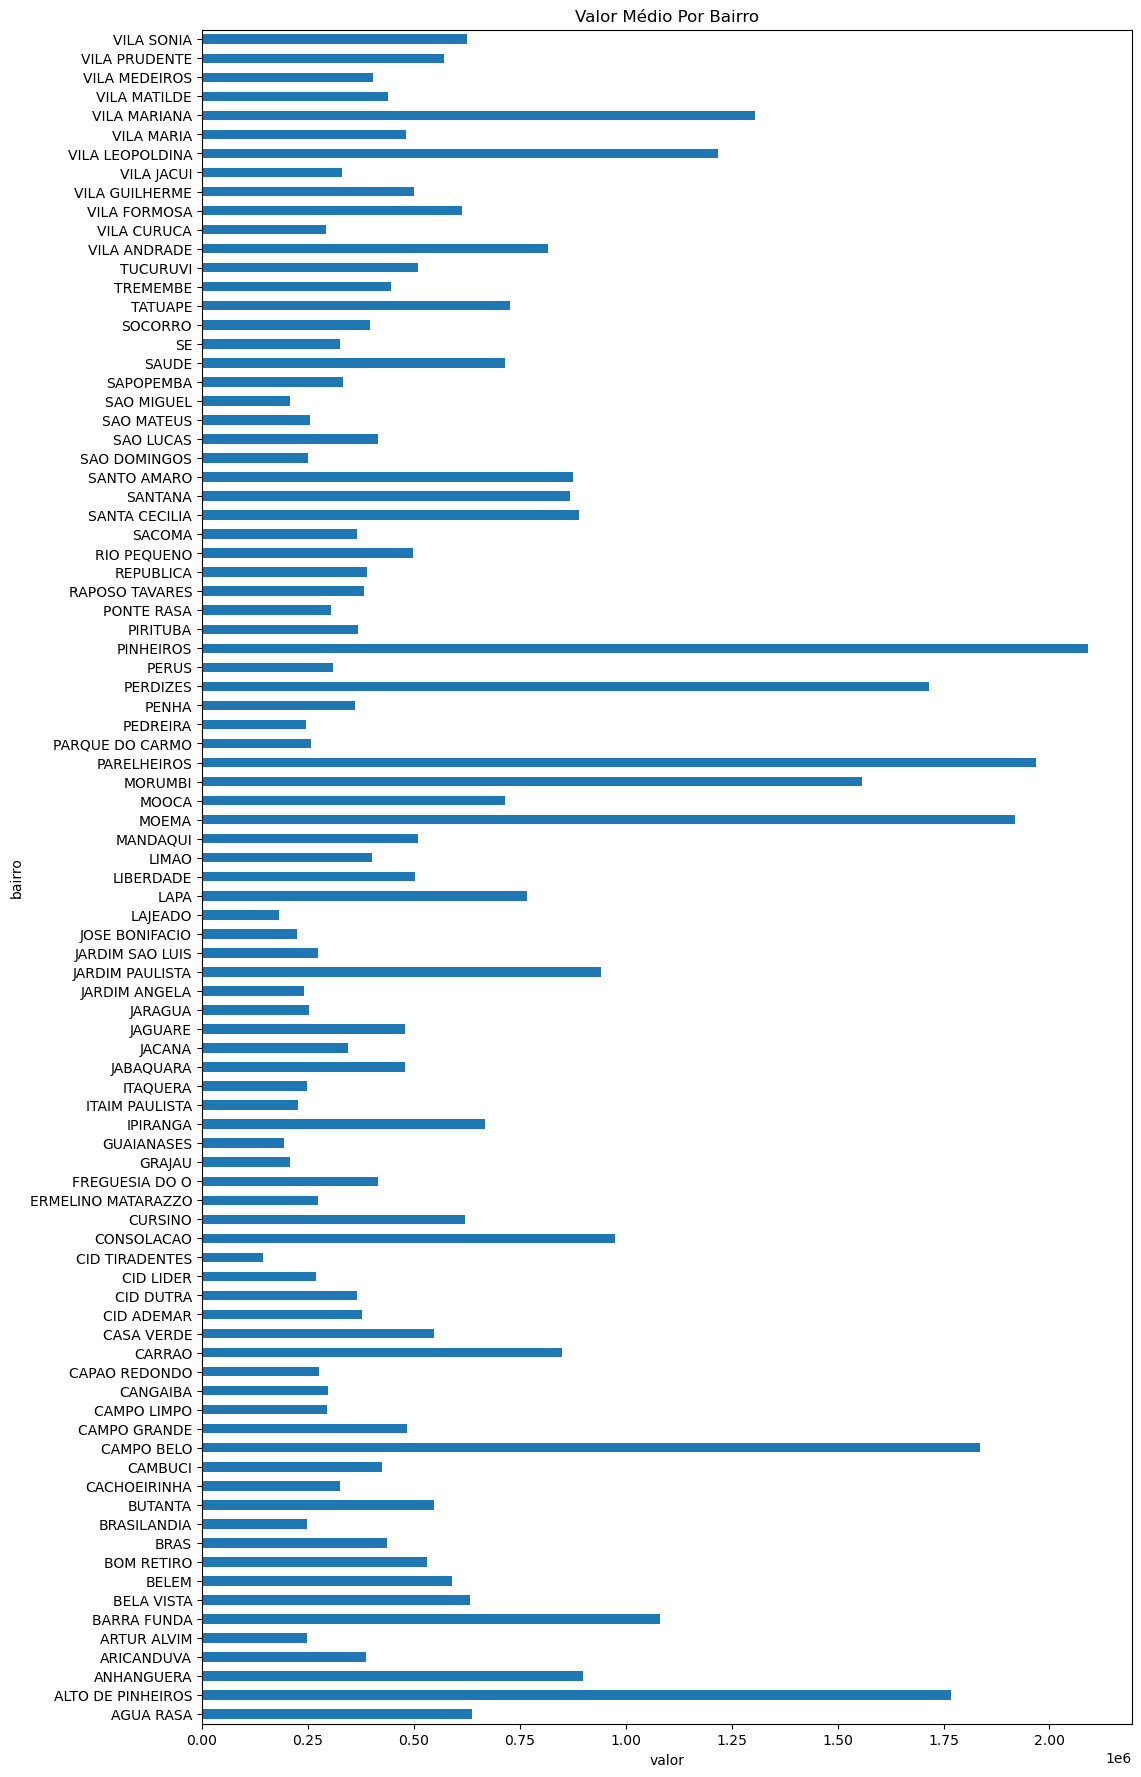

In [165]:
media_valor_total_bairro = df.groupby(['bairro'])['valor_total'].mean()
media_valor_total_bairro

media_valor_total_bairro.plot(kind='barh', figsize=(12, 22), title='Valor Médio Por Bairro', xlabel='valor')


<Axes: xlabel='valor_medio', ylabel='area_util'>

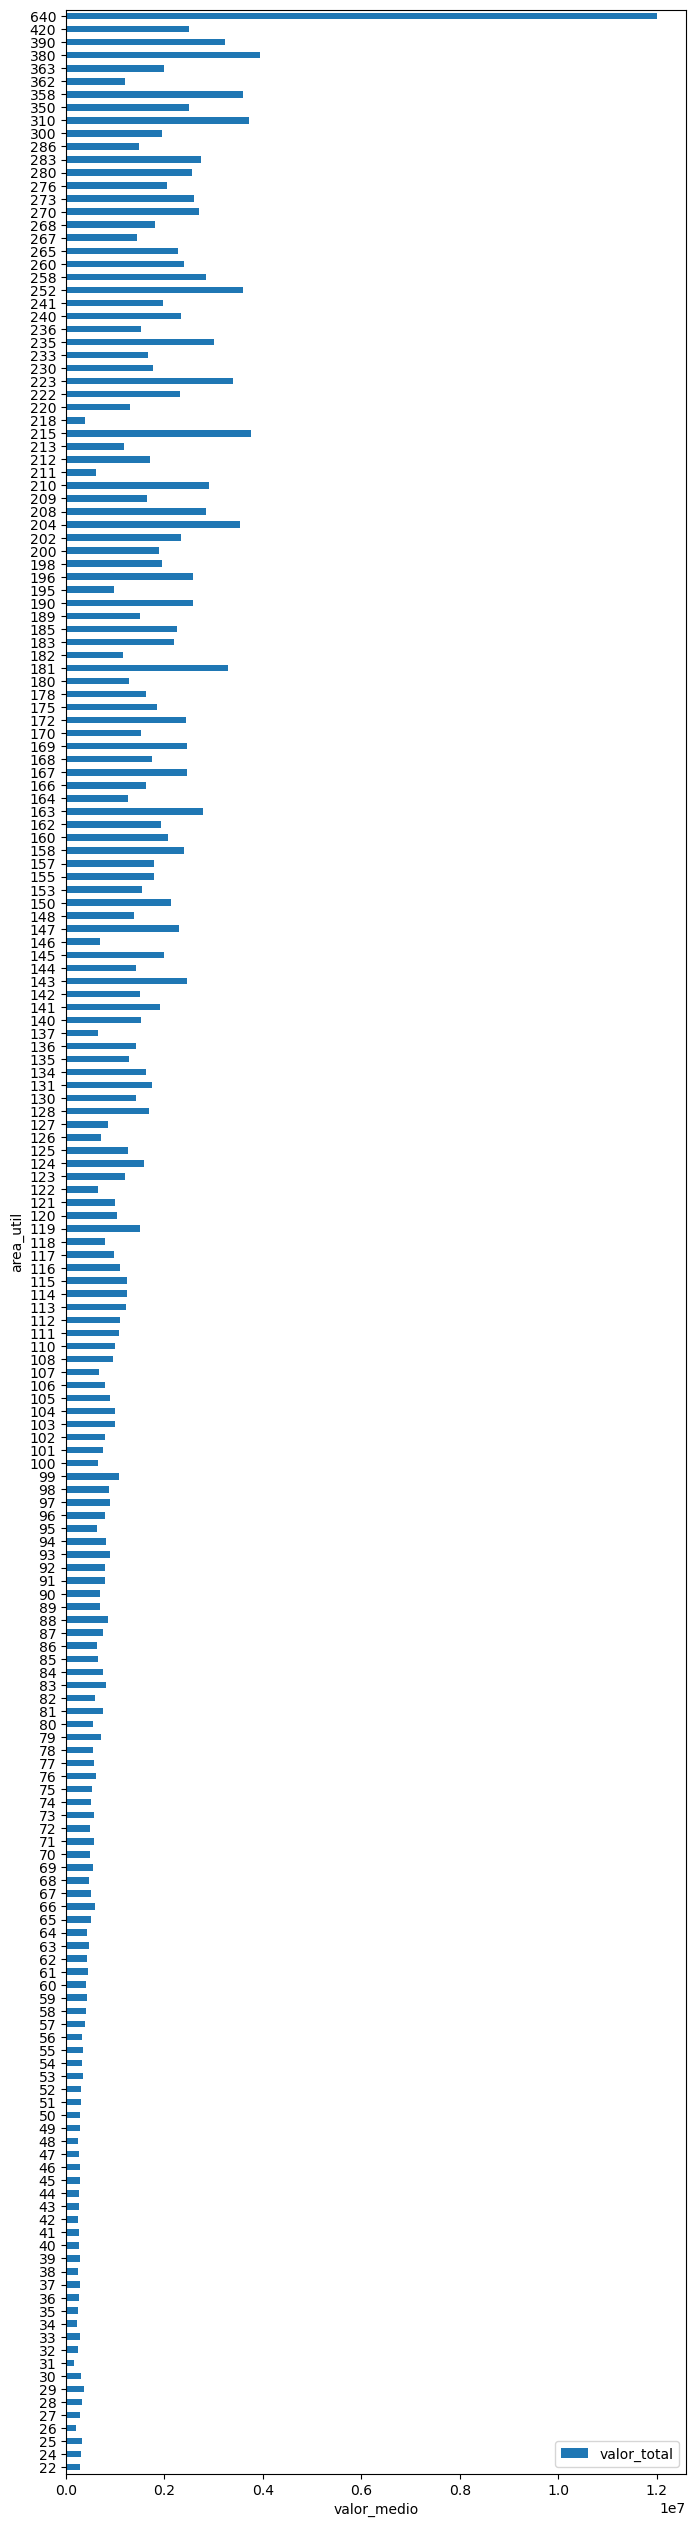

In [166]:
media_valor_area = df.groupby('area_util')[['valor_total']].mean()
media_valor_area
media_valor_area.plot(kind='barh', figsize=(8,32), xlabel='valor_medio', ylabel='area_util') 
